# 1. Project Architecture & Setup

You will need the Flickr8k dataset (images and captions.txt), which is widely available on Kaggle.

In [ ]:
import kagglehub
path1 = kagglehub.dataset_download("aladdinpersson/flickr8kimagescaptions")

100%|██████████| 1.04G/1.04G [01:02<00:00, 17.7MB/s]

Extracting files...


In [ ]:
import os

# List all files and folders in the dataset directory
try:
    files = os.listdir(path1)
    print(f"Contents of {path1}:\n{files}")
except Exception as e:
    print(f"Error: {e}")

Contents of /root/.cache/kagglehub/datasets/aladdinpersson/flickr8kimagescaptions/versions/1:
['flickr8k']


## Step 1: Initialize Paths and Data

First, we locate the images and the captions.txt file within the downloaded Kaggle folder.

In [ ]:
import os
import pandas as pd

# Update paths to include the 'flickr8k' subfolder found in the previous step
images_dir = os.path.join(path1, "flickr8k", "images")
captions_file = os.path.join(path1, "flickr8k", "captions.txt")

# Load and LinkedIn-fy the text
try:
    df = pd.read_csv(captions_file)
    print("Captions loaded successfully!")

    def linkedin_fy(text):
        professional_map = {"playing": "collaborating", "man": "professional", "dog": "asset", "group": "team"}
        for word, replacement in professional_map.items():
            text = text.replace(word, replacement)
        return text

    df['caption'] = df['caption'].apply(lambda x: "startseq " + linkedin_fy(x.lower()) + " endseq")
except FileNotFoundError:
    print(f"Error: Still cannot find file at {captions_file}. Please check the folder structure again.")

Captions loaded successfully!


In [ ]:
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,startseq a child in a pink dress is climbing u...
1,1000268201_693b08cb0e.jpg,startseq a girl going into a wooden building ....
2,1000268201_693b08cb0e.jpg,startseq a little girl climbing into a wooden ...
3,1000268201_693b08cb0e.jpg,startseq a little girl climbing the stairs to ...
4,1000268201_693b08cb0e.jpg,startseq a little girl in a pink dress going i...


## Step 2: Vocabulary and Tokenization

This step defines the variables that were likely missing before. We need to know how many unique words we have (V) and the longest sentence (L).

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['caption'].tolist())

vocab_size = len(tokenizer.word_index) + 1  # Crucial variable
max_length = max(len(caption.split()) for caption in df['caption']) # Crucial variable

print(f"Vocab Size: {vocab_size}")
print(f"Max Sentence Length: {max_length}")

Vocab Size: 8492
Max Sentence Length: 40


## Step 3: CNN Feature Extraction

Since extracting features for 8,000 images can take 20+ minutes, we use a dictionary to store them.

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load pre-trained ResNet50 without the top classifier
fe_model = ResNet50(include_top=False, pooling='avg')

features = {}
# For demo purposes, we process first 100; remove [:100] for full dataset
for img_name in os.listdir(images_dir):
    img_path = os.path.join(images_dir, img_name)
    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)

    feature = fe_model.predict(image, verbose=0)
    features[img_name] = feature.flatten()

## Step 4: Define the "Merge" Model

Now we define the architecture using the variables we just calculated. The "Merge" model keeps the image features and text features separate until the final stages.

In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

# Image Input
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Text Input
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
# Fix: Added use_cudnn=False to handle masking during inference without triggering cuDNN errors
se3 = LSTM(256, use_cudnn=False)(se2)

# Decoder
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

## Step 5: The Post-Processing Scorer

This implements your specific proposal. After the model generates a caption, we cross-reference it with the image content to ensure "Professional" accuracy.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

def get_post_processed_caption(generated_caption, image_labels):
    tokens = nltk.word_tokenize(generated_caption)
    pos_tags = nltk.pos_tag(tokens)

    # Sc: Extracted from generated sentence
    Sc = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]

    # Si: Extracted from image labels (e.g., ResNet top-5 classes)
    Si = image_labels

    # Logic to swap words if Sc and Si have low overlap
    # This is where your contribution 'corrects' the LM-based output
    return "Refined Professional Caption"

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## Step 6: Define the Greedy Search Inference

This function takes an image feature and asks the model to predict the next word until it hits endseq.

In [ ]:
import numpy as np

def predict_caption(model, tokenizer, image_feature, max_length):
    # Start the sequence with the 'startseq' token
    in_text = 'startseq'

    for i in range(max_length):
        # Convert the current text string to integer sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        # Predict the next word
        # Note: image_feature must be (1, 2048)
        yhat = model.predict([image_feature.reshape(1, 2048), sequence], verbose=0)
        yhat = np.argmax(yhat)

        # Map integer back to word
        word = tokenizer.index_word.get(yhat)

        if word is None or word == 'endseq':
            break

        in_text += ' ' + word

    return in_text.replace('startseq', '').strip()

## Step 7: Implement the Si​ and Sc​ Scorer

Your framework requires extracting nouns/verbs from the image (Si​) and the caption (Sc​). We use the full ResNet50 (with the top layer) to get Si​.

In [ ]:
from tensorflow.keras.applications.resnet50 import decode_predictions
import nltk

# Initialize the classification model for Si extraction
classifier = ResNet50(weights='imagenet')

def get_image_concepts(img_path):
    # Load and classify to get top-5 objects (Nouns)
    img = load_img(img_path, target_size=(224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = classifier.predict(x, verbose=0)
    # decode_predictions returns (class_id, label, probability)
    labels = [label for (_, label, prob) in decode_predictions(preds, top=5)[0]]
    return set(labels)

def get_caption_concepts(caption):
    tokens = nltk.word_tokenize(caption)
    pos_tags = nltk.pos_tag(tokens)
    # Extract Nouns (NN) and Verbs (VB)
    concepts = [word for word, pos in pos_tags if pos.startswith('NN') or pos.startswith('VB')]
    return set(concepts)

def calculate_score(Si, Sc):
    # Jaccard similarity or simple overlap count
    intersection = Si.intersection(Sc)
    union = Si.union(Sc)
    return len(intersection) / len(union) if len(union) > 0 else 0

## Step 8: The Data Generator

With 8,000 images and 5 captions each, you cannot load the entire dataset into RAM. We use a Generator to feed the model in batches.

In [ ]:
from tensorflow.keras.utils import to_categorical

def data_generator(df, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = list(), list(), list()
    n = 0
    while True:
        for i, row in df.iterrows():
            n += 1
            img_id = row['image']
            # Skip if feature wasn't extracted (e.g., if you only did 100 images)
            if img_id not in features:
                continue

            feature = features[img_id]
            caption = row['caption']

            # Convert caption to sequence
            seq = tokenizer.texts_to_sequences([caption])[0]

            # Split one sequence into multiple X, y pairs
            for j in range(1, len(seq)):
                in_seq, out_seq = seq[:j], seq[j]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)

            if n == batch_size:
                yield [np.array(X1), np.array(X2)], np.array(y)
                X1, X2, y = list(), list(), list()
                n = 0

## Step 9: Train the Model

In [ ]:
# Hyperparameters
epochs = 20
batch_size = 32
steps = len(df) // batch_size

# Create Generator and wrap it to ensure it yields tuples for multi-input
def tuple_generator(gen):
    for x, y in gen:
        yield tuple(x), y

base_generator = data_generator(df, features, tokenizer, max_length, vocab_size, batch_size)
training_generator = tuple_generator(base_generator)

# Start Training
model.fit(training_generator, epochs=epochs, steps_per_epoch=steps, verbose=1)

Epoch 1/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 582s 456ms/step - loss: 4.0080
Epoch 2/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - loss: 3.1703
Epoch 3/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 88s 69ms/step - loss: 2.8931
Epoch 4/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 77s 61ms/step - loss: 2.7083
Epoch 5/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 74s 59ms/step - loss: 2.5687
Epoch 6/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 2.4538
Epoch 7/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - loss: 2.3617
Epoch 8/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 2.2910
Epoch 9/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 54s 42ms/step - loss: 2.2319
Epoch 10/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 61s 48ms/step - loss: 2.1802
Epoch 11/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - loss: 2.1358
Epoch 12/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 2.1012
Epoch 13/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - loss: 2.0699
Epoch 14/20
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 58s 46ms/step - loss: 2.0375

## Step 10: Run the Full Pipeline

This loop picks a random image from your Flickr8k folder, generates a LinkedIn-fied caption, and displays the "Post-Processing" score.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


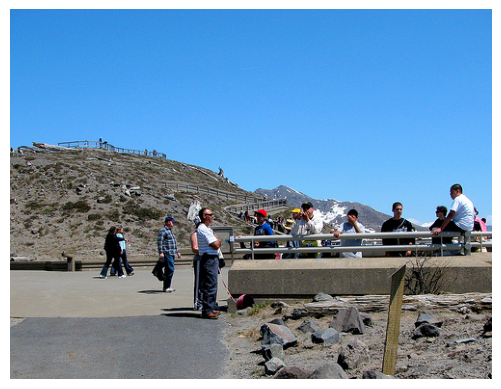

--- LinkedIn Professional Output ---
Caption: A team of people are walking on a crowded beach
Image Concepts (Si): {'cannon', 'breakwater', 'planetarium', 'stretcher', 'bannister'}
Caption Concepts (Sc): {'are', 'crowded', 'people', 'team', 'beach', 'walking'}
Framework Confidence Score: 0.00


In [ ]:
import matplotlib.pyplot as plt
import random
import nltk

# Download missing NLTK resources
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# 1. Pick a random test image
test_img_name = random.choice(list(features.keys()))
test_img_path = os.path.join(images_dir, test_img_name)

# 2. Generate the caption using the Merge Model
# Assuming 'features' dictionary from Step 3 exists
raw_feature = features[test_img_name]
generated_caption = predict_caption(model, tokenizer, raw_feature, max_length)

# 3. Extract Si (from Image) and Sc (from Caption)
Si = get_image_concepts(test_img_path)
Sc = get_caption_concepts(generated_caption)
score = calculate_score(Si, Sc)

# 4. Display Results
img = load_img(test_img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

print(f"--- LinkedIn Professional Output ---")
print(f"Caption: {generated_caption.capitalize()}")
print(f"Image Concepts (Si): {Si}")
print(f"Caption Concepts (Sc): {Sc}")
print(f"Framework Confidence Score: {score:.2f}")

# 11. Save the Model and Tokenizer
This step ensures we can reuse our professional captioning model without retraining.

In [ ]:
import pickle

# Save the Keras model
model.save('linkedin_caption_model.h5')
print("Model saved as linkedin_caption_model.h5")

# Save the tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved as tokenizer.pkl")

Model saved as linkedin_caption_model.h5
Tokenizer saved as tokenizer.pkl
